<h1>Clustering and Ecosystem Pattern Analysis</h1>

<h3>Ivan Komin</h3>

<h3>Group: IP-44</h3>

<h3>Introduction</h3>

This exercise focuses on applying unsupervised machine learning techniques to identify natural groupings and ecological regimes within complex environmental datasets. Using the Forest Cover Type dataset, we will analyze topographic and environmental variables such as elevation, slope, and moisture gradients to uncover patterns without relying on predefined labels.  

<h3>1. Environment Setup and Data Loading</h3>

In this stage, we import the necessary tools and load the dataset. The Forest Cover Type dataset contains measurements from forested areas in the Roosevelt National Forest, USA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import scipy.cluster.hierarchy as sch

# Set random seed for reproducibility
np.random.seed(42)

df = pd.read_csv('covtype.data', header=None)

print("Dataset shape:", df.shape)
display(df.head())

# Initial descriptive analysis
display(df.iloc[:, :10].describe())

Dataset shape: (581012, 55)


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


,0,1,2,3,4,5,6,7,8,9
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000


<h3>2. Feature Selection and Data Preprocessing</h3>

We isolate the relevant environmental drivers and standardize them to ensure distance-based algorithms operate correctly.

In [ ]:
# Select only the first 10 columns (continuous environmental/topographic variables)
continuous_features = df.columns[:10]
X = df[continuous_features].values

# Standardization (zero mean and unit variance)
# This is critical so that high-magnitude variables (like Elevation) 
# do not dominate variables with smaller ranges (like Slope).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Subsampling for performance
# Metrics like Silhouette Score are computationally expensive on 580k+ rows
subset_indices = np.random.choice(len(X_scaled), size=5000, replace=False)
X_subset = X_scaled[subset_indices]

<b>Justification for Feature Selection: </b>The final "cover type" label is intentionally excluded to ensure the model discovers natural patterns rather than replicating existing human-defined classes. Terrain, moisture, and accessibility are selected because they are the primary factors governing ecosystem differentiation.

<h3>3. Internal Validation (Determining k)</h3>

We use the Elbow Method and Silhouette Analysis to explore the optimal number of clusters.

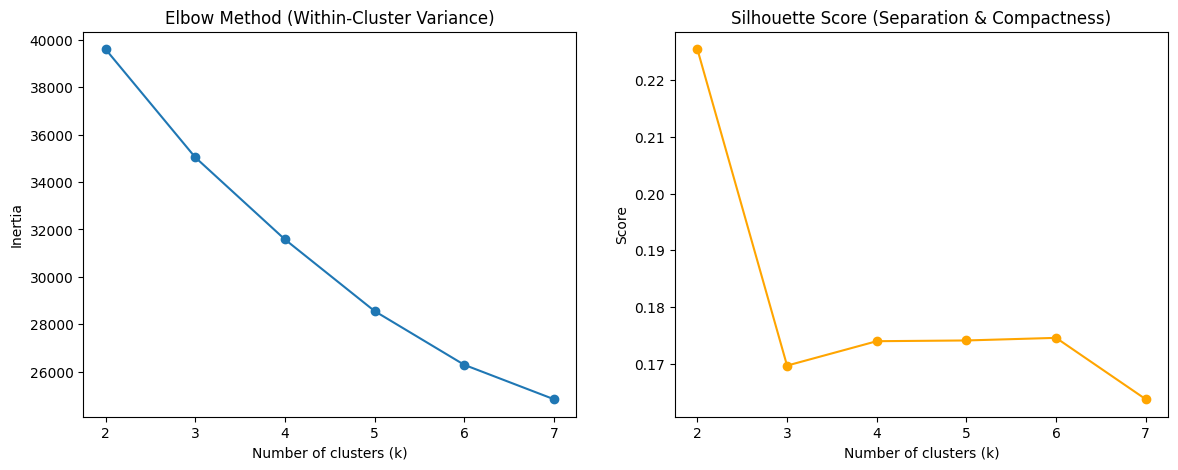

In [3]:
inertia = []
silhouette_scores = []
k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_subset)
    
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_subset, labels)
    silhouette_scores.append(score)

# Visualizing validation results
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(k_values, inertia, marker='o')
ax[0].set_title('Elbow Method (Within-Cluster Variance)')
ax[0].set_xlabel('Number of clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(k_values, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Score (Separation & Compactness)')
ax[1].set_xlabel('Number of clusters (k)')
ax[1].set_ylabel('Score')

plt.show()

<b>Validation Interpretation: </b>We look for a "kink" in the inertia curve where the reduction in variance begins to slow down. Higher scores indicate better-defined, more cohesive clusters. While statistical peaks may occur at $k=6$, we often select $k=4$ to avoid over-partitioning environmental gradients into ecologically uninterpretable units.

<h3>4. K-Means Implementation and Results</h3>

Applying the algorithm to the full dataset using our selected number of clusters.

In [4]:
# Final K-Means application
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

print("Distribution of locations across clusters:")
print(df['Cluster_KMeans'].value_counts())

Distribution of locations across clusters:
Cluster_KMeans
3    240655
2    157682
1    105688
0     76987
Name: count, dtype: int64


<h3>5. Hierarchical Clustering (Dendrogram)</h3>

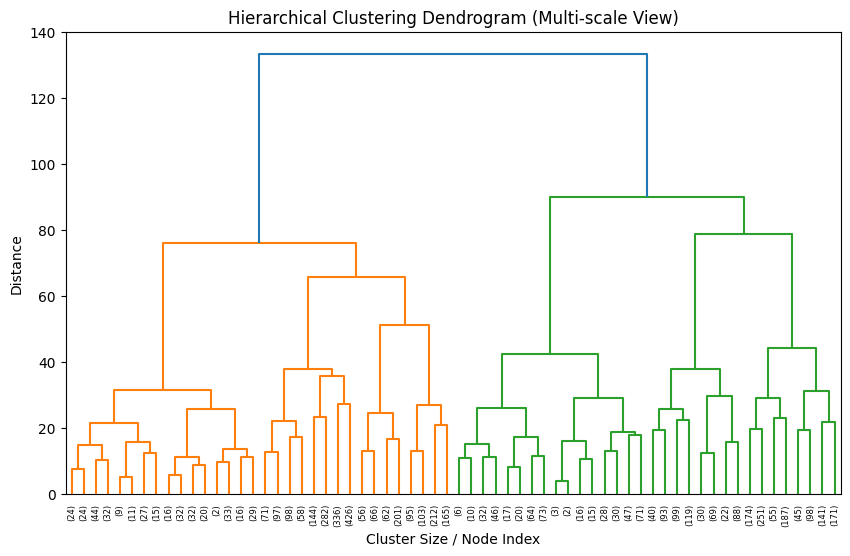

In [ ]:
plt.figure(figsize=(10, 6))

# Linkage using Ward's method to minimize variance within clusters
Z = sch.linkage(X_subset, method='ward')

sch.dendrogram(Z, truncate_mode='level', p=5)

plt.title("Hierarchical Clustering Dendrogram (Multi-scale View)")
plt.xlabel("Cluster Size / Node Index")
plt.ylabel("Distance")
plt.show()

<h3>Reflection and Limitations</h3>

**Algorithm Comparison:** K-Means is scalable for large datasets but requires $k$ to be predefined. Hierarchical clustering reveals multi-scale "nestedness" via the dendrogram but is computationally heavy.  

**Gradual Boundaries:** A major limitation is that ecosystems often have fuzzy or gradual boundaries, which clustering algorithms partition into rigid groups.  

**Decision Support:** These data-driven results complement expert knowledge by providing an objective basis for mapping and conservation in poorly surveyed areas.